## Bank Customer Churn Analysis & Model Implementation

In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [97]:
df = pd.read_csv(r"Bank Customer Churn Prediction.csv")

In [98]:
df_copy = df.copy()

In [99]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [101]:
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Statistical Analysis with Visualization

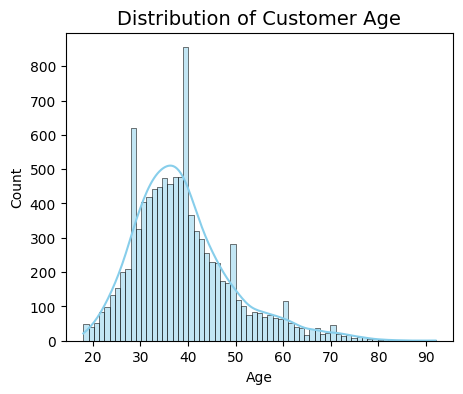

In [102]:
#Age Distribution
plt.figure(figsize=(5,4))
sns.histplot(data=df, x='age', kde=True, color='skyblue')
plt.title("Distribution of Customer Age", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### From dristibution of customer age's, majority age's are between 32 to 44. Age data is right skwed. Some of the data is abouve 70. Also there is some data around 90.

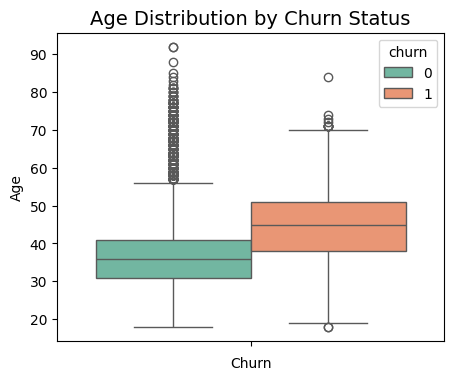

In [103]:
#Boxplot to Check outliers 

plt.figure(figsize=(5,4))
sns.boxplot(data=df, hue='churn', y='age', palette='Set2')
plt.title("Age Distribution by Churn Status", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Age")
# plt.legend(False)
plt.show()

### In this boxplot we can see there is a lot of suspicious outliers. Age may effect the churn in this bank.

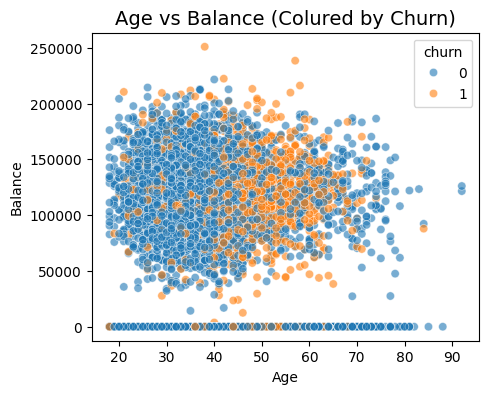

In [104]:
#Scatter plot for Age vs Churn rate

plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='age', y='balance', hue='churn', alpha=0.6)
plt.title("Age vs Balance (Colured by Churn)", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Balance")
plt.show()

### It seems majority of older people no matter how much left in balance has churned

In [105]:
df['country'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [106]:
df['gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [107]:
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

In [108]:
df.head(5)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [109]:
corr_ = df[['credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary','churn','country_Germany','country_Spain','gender_Male']]
corr_matrix = corr_.corr()

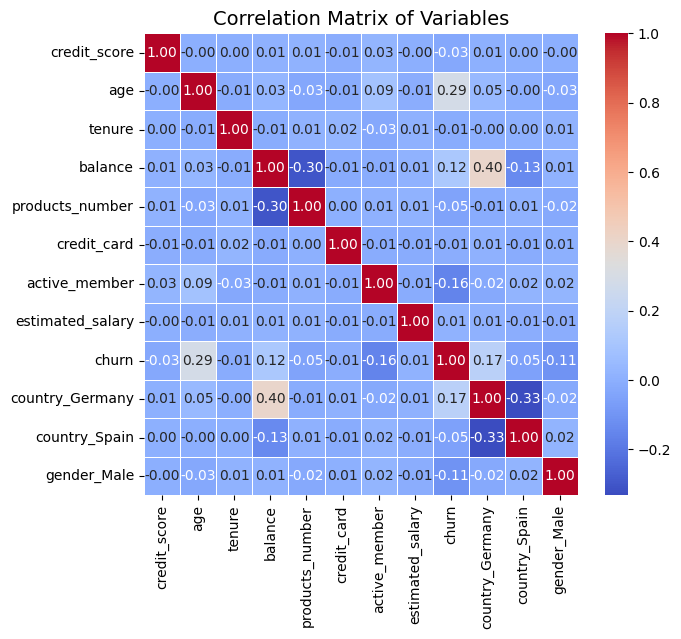

In [110]:
plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Variables", fontsize=14)
plt.show()

## Correlation Heatmap Analysis
### Correlation Heatmap shows us that most of the features in a negative correlation with Churn. Only Age, Balance and People from Germany has the minimum Churn correlation.

In [111]:
scaler = StandardScaler()

In [112]:
X = df.drop(columns=['customer_id','churn'])
y = df['churn']

In [113]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_temp, X_test, y_temp, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### fit_transform on train data points then transform it to the test and validation set. We use fit_transform on training data and transform on test and validation data because we want the same scaling range on test and validation set.

In [114]:
X_train_scaled = scaler.fit_transform(X_train)
X_temp_scaled = scaler.transform(X_temp)
X_test_scaled = scaler.transform(X_test)

In [115]:
model = LogisticRegression(
    # l1_ratio=0,
    C=1,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

In [116]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

In [117]:
#prediction on validation data
y_temp_pred = model.predict(X_temp_scaled)

#prediction on test data
y_test_pred = model.predict(X_test_scaled)

In [118]:
# Evaluation Score on Validation set
print(f"classication Report: {classification_report(y_temp, y_temp_pred)}")
print(f"classication Report: {classification_report(y_test, y_test_pred)}")

classication Report:               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1199
           1       0.40      0.72      0.51       301

    accuracy                           0.73      1500
   macro avg       0.66      0.72      0.66      1500
weighted avg       0.81      0.73      0.75      1500

classication Report:               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1190
           1       0.39      0.74      0.51       310

    accuracy                           0.71      1500
   macro avg       0.65      0.72      0.65      1500
weighted avg       0.80      0.71      0.74      1500

